# CubeSat Attitude Determination & Control System (ADCS)

**Author:** Salim Saadoon — Aerospace Engineering, Wichita State University

---

This notebook simulates a full 3-axis attitude control system for a 3U CubeSat.
It models the satellite starting in a 30° off-axis tumble and stabilizing to the target orientation.

| Component | Description |
|---|---|
| Quaternion kinematics | Orientation represented as quaternions to avoid gimbal lock |
| Euler rigid body dynamics | Physics of how torque affects a spinning body |
| PD controller | Computes corrective torque from attitude error |
| Reaction wheel saturation | Actuator torque limited to 1 mNm (realistic hardware limit) |
| Disturbance torques | Gravity gradient, solar radiation pressure, magnetic disturbances |
| Gyroscope bias | Sensor drift added to angular velocity measurements |
| TRIAD algorithm | Estimates attitude from magnetometer and sun sensor readings |

---

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [5]:
def quat_mult(q1, q2):
    """Hamilton product: q1 x q2. Convention: q = [w, x, y, z]."""
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
    ])

def quat_conj(q):
    """Conjugate (inverse for unit quaternion)."""
    return np.array([q[0], -q[1], -q[2], -q[3]])

def quat_norm(q):
    """Normalize quaternion to unit length."""
    return q / np.linalg.norm(q)

def quat_to_euler(q):
    """Convert unit quaternion to roll-pitch-yaw in degrees."""
    w, x, y, z = q
    roll  = np.degrees(np.arctan2(2*(w*x + y*z), 1 - 2*(x*x + y*y)))
    pitch = np.degrees(np.arcsin(np.clip(2*(w*y - z*x), -1, 1)))
    yaw   = np.degrees(np.arctan2(2*(w*z + x*y), 1 - 2*(y*y + z*z)))
    return np.array([roll, pitch, yaw])

def rotation_matrix_to_quaternion(R):
    """Convert a 3x3 rotation matrix to a unit quaternion [w, x, y, z]."""
    trace = R[0,0] + R[1,1] + R[2,2]
    if trace > 0:
        s = 0.5 / np.sqrt(trace + 1.0)
        w = 0.25 / s
        x = (R[2,1] - R[1,2]) * s
        y = (R[0,2] - R[2,0]) * s
        z = (R[1,0] - R[0,1]) * s
    elif R[0,0] > R[1,1] and R[0,0] > R[2,2]:
        s = 2.0 * np.sqrt(1.0 + R[0,0] - R[1,1] - R[2,2])
        w = (R[2,1] - R[1,2]) / s
        x = 0.25 * s
        y = (R[0,1] + R[1,0]) / s
        z = (R[0,2] + R[2,0]) / s
    elif R[1,1] > R[2,2]:
        s = 2.0 * np.sqrt(1.0 + R[1,1] - R[0,0] - R[2,2])
        w = (R[0,2] - R[2,0]) / s
        x = (R[0,1] + R[1,0]) / s
        y = 0.25 * s
        z = (R[1,2] + R[2,1]) / s
    else:
        s = 2.0 * np.sqrt(1.0 + R[2,2] - R[0,0] - R[1,1])
        w = (R[1,0] - R[0,1]) / s
        x = (R[0,2] + R[2,0]) / s
        y = (R[1,2] + R[2,1]) / s
        z = 0.25 * s
    return quat_norm(np.array([w, x, y, z]))

print("Quaternion functions ready!")

Quaternion functions ready!


In [6]:
# Inertia tensor (kg/m^2) - describes how mass is distributed around each axis
I     = np.diag([0.004, 0.004, 0.002])
I_inv = np.linalg.inv(I)

# PD controller gains
Kp = 0.015   # proportional: how hard to push based on angle error
Kd = 0.005   # derivative: how hard to brake as we approach target

# Reaction wheel torque limit (N/m) - hardware constraint
max_torque = 0.001   # 1 mNm, typical for a 3U CubeSat wheel

# Gyroscope sensor bias - constant drift in angular velocity measurement
gyro_bias = np.array([0.0005, -0.0003, 0.0002])

def disturbances(t):
    """Returns total disturbance torque vector at time t (N/m)."""
    gravity_gradient = np.array([
        1e-6 * np.sin(0.001 * t),
        1e-6 * np.cos(0.001 * t),
        5e-7 * np.sin(0.002 * t)
    ])
    solar_pressure = np.array([2e-7, -1e-7, 1e-7])
    magnetic = np.array([
        3e-7 * np.sin(0.003 * t),
        2e-7 * np.cos(0.003 * t),
        1e-7 * np.sin(0.001 * t)
    ])
    return gravity_gradient + solar_pressure + magnetic

def dynamics(t, state, q_ref):
    """
    State vector: [q0, q1, q2, q3, wx, wy, wz]
    q = current quaternion (body frame w.r.t. inertial frame)
    w = angular velocity in body frame (rad/s)
    """
    q = quat_norm(state[:4])
    w = state[4:]

    # Gyroscope measurement includes bias
    w_measured = w + gyro_bias

    # Error quaternion: how far are we from the target?
    q_err = quat_mult(quat_conj(q_ref), q)
    if q_err[0] < 0:
        q_err = -q_err

    # PD control torque, clipped to reaction wheel limit
    torque = np.clip(-Kp * q_err[1:] - Kd * w_measured, -max_torque, max_torque)

    # Total torque = control + disturbances
    torque_total = torque + disturbances(t)

    # Quaternion kinematics
    q_dot = 0.5 * quat_mult(q, np.array([0.0, w[0], w[1], w[2]]))

    # Euler rigid body equations
    w_dot = I_inv @ (torque_total - np.cross(w, I @ w))

    return np.concatenate([q_dot, w_dot])

print("Dynamics model ready!")

Dynamics model ready!


In [7]:
def triad(v1b, v2b, v1r, v2r):
    """
    Estimate rotation matrix from two vector pairs.
    v1b, v2b = vectors measured by sensors in body frame
    v1r, v2r = same vectors known in inertial reference frame
    """
    v1b = v1b / np.linalg.norm(v1b);  v2b = v2b / np.linalg.norm(v2b)
    v1r = v1r / np.linalg.norm(v1r);  v2r = v2r / np.linalg.norm(v2r)

    t1b = v1b
    t2b = np.cross(v1b, v2b);  t2b /= np.linalg.norm(t2b)
    t3b = np.cross(t1b, t2b)

    t1r = v1r
    t2r = np.cross(v1r, v2r);  t2r /= np.linalg.norm(t2r)
    t3r = np.cross(t1r, t2r)

    return np.column_stack([t1b, t2b, t3b]) @ np.column_stack([t1r, t2r, t3r]).T

def simulate_sensors(q_true):
    """
    Simulate magnetometer and sun sensor readings.
    Rotates known reference vectors into body frame, then adds sensor noise.
    """
    mag_ref = np.array([0.3, 0.5, 0.8])   # Earth magnetic field (inertial frame)
    sun_ref = np.array([1.0, 0.0, 0.0])   # Sun direction (inertial frame)

    def rotate(v):
        w = np.array([0.0, *v])
        return quat_mult(quat_mult(quat_conj(q_true), w), q_true)[1:]

    mag_body = rotate(mag_ref) + np.random.normal(0, 0.01, 3)
    sun_body = rotate(sun_ref) + np.random.normal(0, 0.01, 3)

    return mag_body, sun_body, mag_ref, sun_ref

print("TRIAD algorithm ready!")

TRIAD algorithm ready!


In [8]:
# Target attitude: no rotation from inertial frame (nadir pointing)
q_ref = np.array([1.0, 0.0, 0.0, 0.0])

# Initial condition: 30 degrees off-axis tumble
angle  = np.radians(30)
q0     = quat_norm(np.array([np.cos(angle/2), np.sin(angle/2)*0.6,
                               np.sin(angle/2)*0.8, 0.0]))
w0     = np.array([0.05, -0.03, 0.02])
state0 = np.concatenate([q0, w0])

# Integrate over 120 seconds
sol = solve_ivp(
    dynamics, (0, 120), state0,
    t_eval=np.linspace(0, 120, 600),
    args=(q_ref,), method='RK45',
    rtol=1e-6, atol=1e-8
)

# Extract and process results
qs     = np.array([quat_norm(sol.y[:4, i]) for i in range(sol.y.shape[1])])
ws     = sol.y[4:].T
eulers = np.array([quat_to_euler(q) for q in qs])

# Run TRIAD every 10th timestep
triad_eulers, triad_times = [], []
for i in range(0, len(sol.t), 10):
    mb, sb, mr, sr = simulate_sensors(qs[i])
    R   = triad(mb, sb, mr, sr)
    q_e = rotation_matrix_to_quaternion(R)
    triad_eulers.append(quat_to_euler(q_e))
    triad_times.append(sol.t[i])

triad_eulers = np.array(triad_eulers)
triad_times  = np.array(triad_times)

print("Simulation complete!")
print(f"Final true attitude:  {eulers[-1].round(4)} degrees")
print(f"Final TRIAD estimate: {triad_eulers[-1].round(4)} degrees")
print(f"Estimation error:     {(eulers[-1] - triad_eulers[-1]).round(4)} degrees")

Simulation complete!
Final true attitude:  [-0.0159  0.0197 -0.0059] degrees
Final TRIAD estimate: [0.6377 0.4817 0.4923] degrees
Estimation error:     [-0.6536 -0.4619 -0.4981] degrees


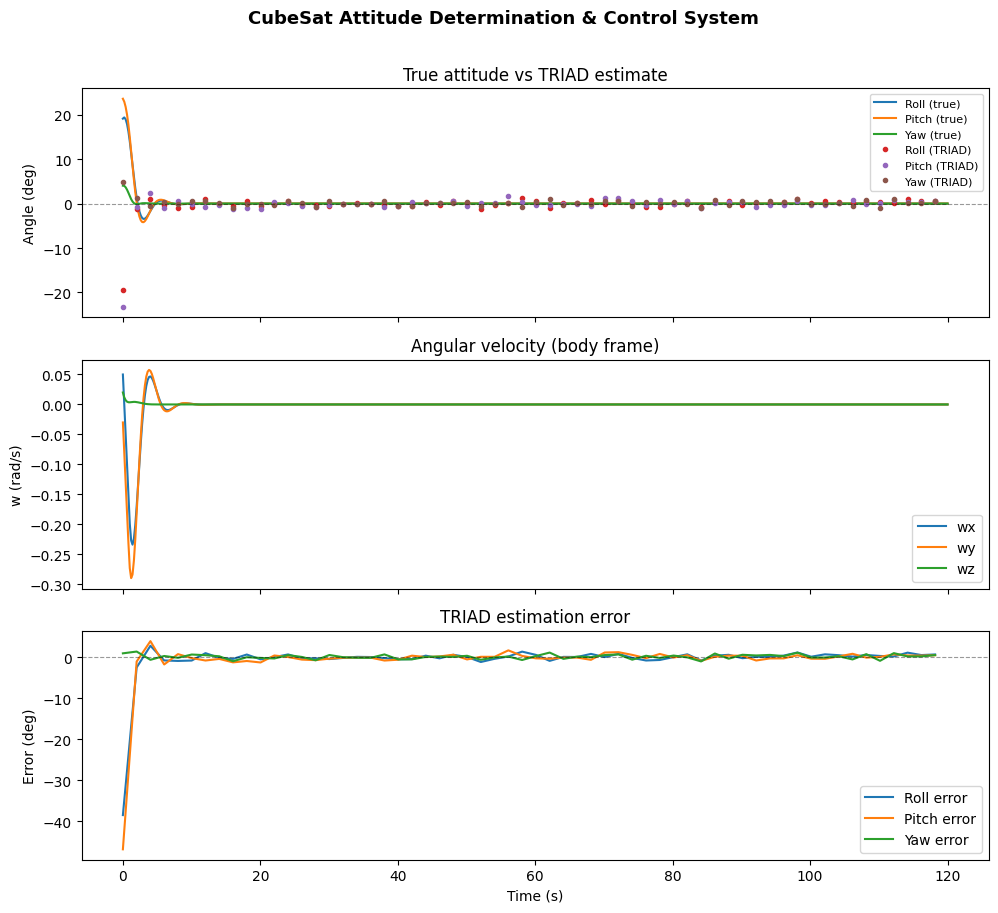

Saved!


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# Plot 1: True attitude vs TRIAD estimate
axes[0].plot(sol.t, eulers[:, 0], label='Roll (true)')
axes[0].plot(sol.t, eulers[:, 1], label='Pitch (true)')
axes[0].plot(sol.t, eulers[:, 2], label='Yaw (true)')
axes[0].plot(triad_times, triad_eulers[:, 0], 'o', ms=3, label='Roll (TRIAD)')
axes[0].plot(triad_times, triad_eulers[:, 1], 'o', ms=3, label='Pitch (TRIAD)')
axes[0].plot(triad_times, triad_eulers[:, 2], 'o', ms=3, label='Yaw (TRIAD)')
axes[0].axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
axes[0].set_ylabel('Angle (deg)')
axes[0].set_title('True attitude vs TRIAD estimate')
axes[0].legend(fontsize=8)

# Plot 2: Angular velocity
axes[1].plot(sol.t, ws[:, 0], label='wx')
axes[1].plot(sol.t, ws[:, 1], label='wy')
axes[1].plot(sol.t, ws[:, 2], label='wz')
axes[1].set_ylabel('w (rad/s)')
axes[1].set_title('Angular velocity (body frame)')
axes[1].legend()

# Plot 3: TRIAD estimation error
estimation_error = triad_eulers - eulers[::10]
axes[2].plot(triad_times, estimation_error[:, 0], label='Roll error')
axes[2].plot(triad_times, estimation_error[:, 1], label='Pitch error')
axes[2].plot(triad_times, estimation_error[:, 2], label='Yaw error')
axes[2].axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
axes[2].set_ylabel('Error (deg)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('TRIAD estimation error')
axes[2].legend()

plt.suptitle('CubeSat Attitude Determination & Control System',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

plt.savefig('cubesat_adcs.pdf', bbox_inches='tight')
plt.savefig('cubesat_adcs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")